In [62]:
import os
from pathlib import Path
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import scipy.stats

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import shap
from sklearn.model_selection import train_test_split, ParameterGrid
from scipy.signal import butter, sosfilt

In [63]:
# =====================================================================
# 1. PARÂMETROS
# =====================================================================
SAMPLE_RATE = 16_000

DCASE2022_DEV_PATH = Path(r"C:\Users\josel\OneDrive\Desktop\NCIA\data\raw\dcase-2024\Dev") 
MACHINE_TYPE = 'fan'
TARGET_SECTION = 'section_00'

In [64]:
# =====================================================================
# 2. TRATAMENTO DE ÁUDIO E FEATURE EXTRACTION
# =====================================================================
# --- Funções de Limpeza de Áudio ---
def highpass_filter(signal, sr=16000, cutoff=80, order=4):
    nyq = 0.5 * sr
    cutoff_n = cutoff / nyq
    sos = butter(order, cutoff_n, btype="highpass", output="sos")
    return sosfilt(sos, signal).astype(np.float32)

def peak_normalize(signal):
    peak = np.max(np.abs(signal))
    if peak > 0:
        return signal / peak
    return signal

def extract_features(file_path):
    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
    
    #signal = highpass_filter(signal) 
    # signal = peak_normalize(signal) 
    
    rms = np.sqrt(np.mean(signal**2))
    kurt = scipy.stats.kurtosis(signal)
    skew = scipy.stats.skew(signal)
    p2p = np.ptp(signal) 
    crest = np.max(np.abs(signal)) / (rms + 1e-8) 
    mean_val = np.mean(signal)
    std_val = np.std(signal)
    
    hist, _ = np.histogram(signal, bins=256, density=True)
    hist = hist[hist > 0]
    entropy = scipy.stats.entropy(hist)

    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=32)
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=32)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
   
    mfccs_mean = np.mean(mfccs, axis=1)
    mfccs_std = np.std(mfccs, axis=1) 
    mel_mean = np.mean(mel_db, axis=1)
    basic_features = np.array([rms, kurt, skew, p2p, crest, mean_val, std_val, entropy]) 
    
    return np.concatenate([basic_features, mfccs_mean])
    
    # return basic_features

In [65]:
# =====================================================================
# 3. LEITURA E SEPARAÇÃO DOS DADOS
# =====================================================================
print(f"Lendo dados da máquina '{MACHINE_TYPE}' - Seção '{TARGET_SECTION}'...")

X_train_raw, y_train_raw = [], []
X_test_all, y_test_all = [], []
feature_names = ["RMS", "Kurtosis", "Skewness", "Peak-to-Peak", "Crest_Factor", "Mean", "Std", "Entropy"]
machine_dir = DCASE2022_DEV_PATH / MACHINE_TYPE

for f in tqdm(list((machine_dir / 'train').rglob('*.wav')), desc="Extraindo Treino"):
    if TARGET_SECTION in f.name:
        X_train_raw.append(extract_features(f))
        y_train_raw.append(0)

for f in tqdm(list((machine_dir / 'test').rglob('*.wav')), desc="Extraindo Avaliação"):
    if TARGET_SECTION in f.name:
        X_test_all.append(extract_features(f))
        label = 1 if 'anomaly' in f.name else 0
        y_test_all.append(label)

X_train_raw = np.array(X_train_raw)
y_train_raw = np.array(y_train_raw)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_test_all, y_test_all, test_size=0.7, random_state=42, stratify=y_test_all
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

Lendo dados da máquina 'fan' - Seção 'section_00'...


Extraindo Avaliação: 100%|██████████| 200/200 [00:07<00:00, 27.90it/s]


In [69]:
# =====================================================================
# 4. EXHAUSTIVE GRID SEARCH (No Conjunto de Validação)
# =====================================================================
print("\n" + "="*50)
print("INICIANDO FINE-TUNING DE HIPERPARÂMETROS")
print("="*50)

# --- ESPAÇO DE BUSCA OCSVM (90 combinações) ---
param_grid_ocsvm = {
    'nu': [0.001, 0.01, 0.05, 0.1, 0.2],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 0.5],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

best_auc_ocsvm = 0
best_ocsvm = None
best_params_ocsvm = {}

grid_ocsvm = list(ParameterGrid(param_grid_ocsvm))
print(f"Testando {len(grid_ocsvm)} combinações para o One-Class SVM...")

for params in tqdm(grid_ocsvm, desc="OCSVM Grid"):
    ocsvm = OneClassSVM(**params)
    ocsvm.fit(X_train_scaled)
    scores_val = -ocsvm.decision_function(X_val_scaled)
    auc_val = roc_auc_score(y_val, scores_val)
    
    if auc_val > best_auc_ocsvm:
        best_auc_ocsvm = auc_val
        best_ocsvm = ocsvm
        best_params_ocsvm = params

print(f"-> Melhor OCSVM AUC-Val: {best_auc_ocsvm:.2%} | Params: {best_params_ocsvm}")

# --- ESPAÇO DE BUSCA ISOLATION FOREST (216 combinações) ---
param_grid_if = {
    'n_estimators': [100, 300, 500, 1000, 10000],
    'max_samples': ['auto', 0.5, 0.8],
    'contamination': ['auto', 0.01, 0.05, 0.1, 0.15, 0.2],
    'max_features': [0.5, 0.8, 1.0]
}

best_auc_if = 0
best_iforest = None
best_params_if = {}

grid_if = list(ParameterGrid(param_grid_if))
print(f"\nTestando {len(grid_if)} combinações para o Isolation Forest...")

for params in tqdm(grid_if, desc="iForest Grid"):
    iforest = IsolationForest(**params, random_state=42)
    iforest.fit(X_train_scaled)
    scores_val = -iforest.decision_function(X_val_scaled)
    auc_val = roc_auc_score(y_val, scores_val)
    
    if auc_val > best_auc_if:
        best_auc_if = auc_val
        best_iforest = iforest
        best_params_if = params

print(f"-> Melhor Isolation Forest AUC-Val: {best_auc_if:.2%} | Params: {best_params_if}")


INICIANDO FINE-TUNING DE HIPERPARÂMETROS
Testando 90 combinações para o One-Class SVM...


OCSVM Grid: 100%|██████████| 90/90 [00:00<00:00, 129.84it/s]


-> Melhor OCSVM AUC-Val: 70.89% | Params: {'gamma': 0.1, 'kernel': 'rbf', 'nu': 0.01}

Testando 270 combinações para o Isolation Forest...


iForest Grid: 100%|██████████| 270/270 [09:11<00:00,  2.04s/it]

-> Melhor Isolation Forest AUC-Val: 64.11% | Params: {'contamination': 'auto', 'max_features': 0.5, 'max_samples': 0.8, 'n_estimators': 100}



AVALIAÇÃO NO CONJUNTO DE TESTE FINAL (INTOCADO)

[1] RESULTADOS: best One-Class SVM
ROC-AUC Teste: 71.41%
Relatório de Classificação:
              precision    recall  f1-score   support

  Normal (0)       0.70      0.20      0.31        70
Anomalia (1)       0.53      0.91      0.67        70

    accuracy                           0.56       140
   macro avg       0.62      0.56      0.49       140
weighted avg       0.62      0.56      0.49       140


[2] RESULTADOS: Melhor Isolation Forest
ROC-AUC Teste: 53.63%
Relatório de Classificação:
              precision    recall  f1-score   support

  Normal (0)       0.52      0.60      0.56        70
Anomalia (1)       0.53      0.44      0.48        70

    accuracy                           0.52       140
   macro avg       0.52      0.52      0.52       140
weighted avg       0.52      0.52      0.52       140



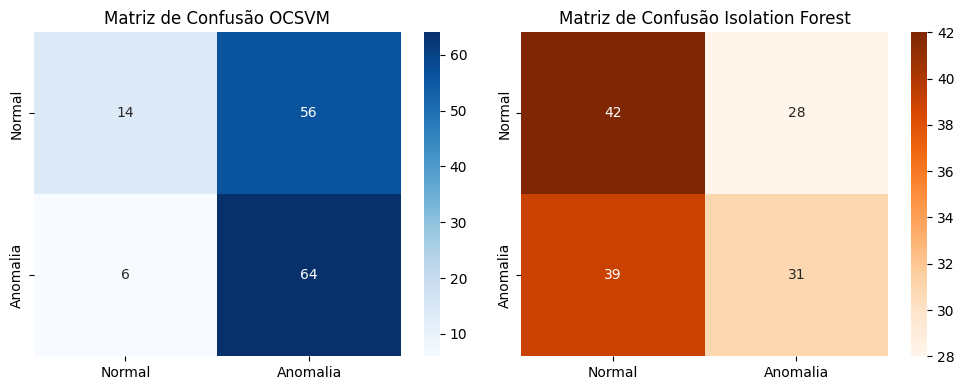

In [70]:
# =====================================================================
# 5. TESTE FINAL
# =====================================================================
print("\n" + "="*50)
print("AVALIAÇÃO NO CONJUNTO DE TESTE FINAL (INTOCADO)")
print("="*50)

# --- Teste do OCSVM ---
scores_test_ocsvm = -best_ocsvm.decision_function(X_test_scaled)
preds_test_ocsvm = [1 if x == -1 else 0 for x in best_ocsvm.predict(X_test_scaled)]
auc_test_ocsvm = roc_auc_score(y_test, scores_test_ocsvm)

print(f"\n[1] RESULTADOS: best One-Class SVM")
print(f"ROC-AUC Teste: {auc_test_ocsvm:.2%}")
print("Relatório de Classificação:")
print(classification_report(y_test, preds_test_ocsvm, target_names=['Normal (0)', 'Anomalia (1)'], zero_division=0))

# --- Teste do Isolation Forest ---
scores_test_if = -best_iforest.decision_function(X_test_scaled)
preds_test_if = [1 if x == -1 else 0 for x in best_iforest.predict(X_test_scaled)]
auc_test_if = roc_auc_score(y_test, scores_test_if)

print(f"\n[2] RESULTADOS: Melhor Isolation Forest")
print(f"ROC-AUC Teste: {auc_test_if:.2%}")
print("Relatório de Classificação:")
print(classification_report(y_test, preds_test_if, target_names=['Normal (0)', 'Anomalia (1)'], zero_division=0))

# =====================================================================
# 6. MATRIZES DE CONFUSÃO VISUAIS
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_ocsvm = confusion_matrix(y_test, preds_test_ocsvm)
sns.heatmap(cm_ocsvm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Normal', 'Anomalia'], yticklabels=['Normal', 'Anomalia'])
axes[0].set_title(f'Matriz de Confusão OCSVM')

cm_if = confusion_matrix(y_test, preds_test_if)
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Oranges', ax=axes[1], xticklabels=['Normal', 'Anomalia'], yticklabels=['Normal', 'Anomalia'])
axes[1].set_title(f'Matriz de Confusão Isolation Forest')

plt.tight_layout()
plt.show()


--- Gerando Explicabilidade (SHAP) para o Isolation Forest---


IndexError: list index out of range

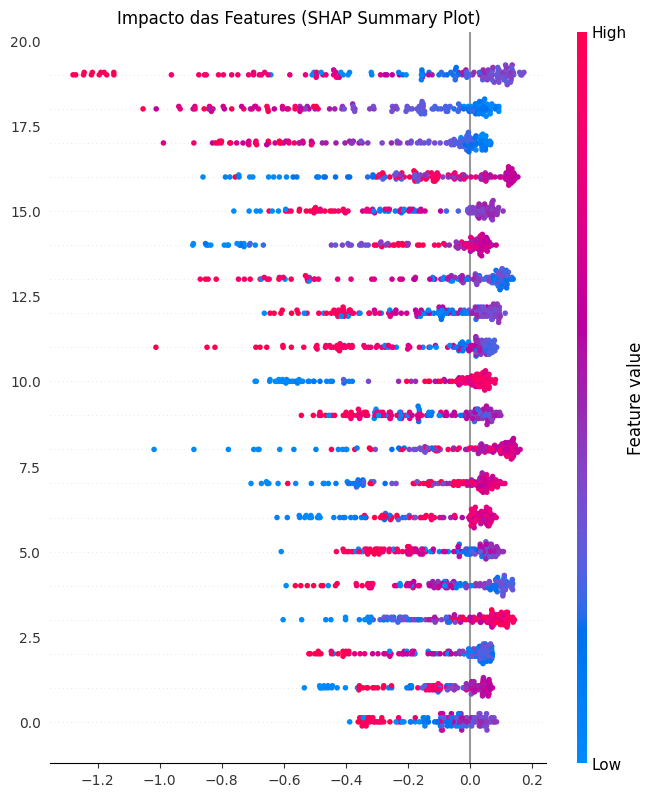

In [68]:
# =====================================================================
# 7. EXPLICABILIDADE AVANÇADA COM SHAP
# =====================================================================
print("\n--- Gerando Explicabilidade (SHAP) para o Isolation Forest---")
explainer = shap.TreeExplainer(best_iforest)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(10, 6))
plt.title(f"Impacto das Features (SHAP Summary Plot)")
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv, X_test_scaled, feature_names=feature_names)